<a href="https://colab.research.google.com/github/NietoEmmanuel/SIMULACION-I/blob/main/Generaci%C3%B3n_de_variables_aleatorias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generación de variables aleatorias discretas
Ejemplo: Simular una variable X tal que:
$P_{1}=0.20$, $P_{2}=0.15$, $P_{3}=0.25$, $P_{4}=0.40$
donde:
$P_{j}=$ P{X=j}

Tenemos que la grafica de la frecuencia acumulativa es:

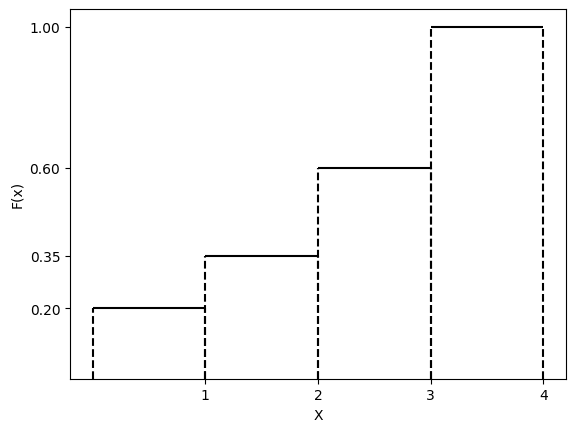

In [23]:
valores = [1, 2, 3, 4]
F = [0.20, 0.35, 0.60, 1.0]
plt.vlines([0,1,2,3], 0, F, linestyles='dashed', colors='black')
plt.vlines([1,2,3,4], 0, F, linestyles='dashed', colors='black')
plt.hlines(F, [0,1,2,3], [1,2,3,4], colors='black')
plt.xticks(valores)
plt.yticks(F)
plt.xlabel('X')
plt.ylabel('F(x)')
plt.ylim(0, 1.05)
plt.show()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

In [7]:
def f(n):
    L = []
    for _ in range(n):
        R = np.random.uniform(0, 1)
        if 0 <= R <= 0.2:
            x = 1
        elif 0.2 < R <= 0.35:
            x = 2
        elif 0.35 < R <= 0.60:
            x = 3
        else:                    # 0.60 < R <= 1
            x = 4
        L.append(x)
    return L

In [8]:
M = f(100000)

(array([0.66846667, 0.        , 0.        , 0.49746667, 0.        ,
        0.        , 0.836     , 0.        , 0.        , 1.3314    ]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

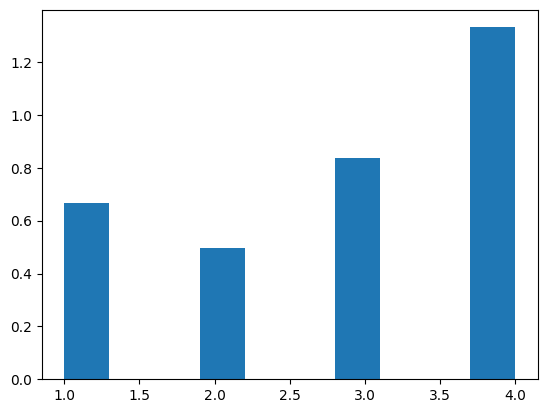

In [9]:
plt.hist(M, density=True)

# Generación de una variable Poisson
La distribución de Poisson sirve para modelar la probabilidad de que ocurra un número determinado de eventos discretos (como llamadas, fallos o llegadas) en un intervalo continuo de tiempo, espacio, área o volumen.
Sus aplicaciones prácticas abarcan sectores como:
1.   Telecomunicaciones: Modelado del número de llamadas entrantes en una central telefónica o solicitudes de conexión a un servidor por minuto.
2.   Medicina y Salud: Predicción de la incidencia de enfermedades raras, brotes epidemiológicos o reacciones adversas a medicamentos en una población.
3.   Control de Calidad: Conteo de defectos o imperfecciones en rollos de tela,lotes de productos o fallas en el ensamblaje por unidad de área o longitud.
4.   Elemento de lista

Una variable X es de Poisson con media $\lambda$ si:

$$
P_{i}=P(X=i)=\frac{e^{-\lambda}\lambda^i}{i!}, \qquad i=0,1,2,\dots
$$

Donde:\
 $P(X = i)$: Es la probabilidad de que ocurran exactamente \(k\) eventos en un intervalo específico. \
$i$: Es la variable aleatoria. Representa el número exacto de eventos o sucesos cuya probabilidad se desea calcular \
$\lambda$: Representa el número promedio esperado de ocurrencias del evento.\
Para simular esta variable usaremos la identidad:
$$
P_{i+1}=\frac{\lambda }{i+1}P_{i}, \qquad i=0,1,2,\dots
$$

In [10]:
def poisson_inversa(lam):
    U = np.random.uniform(0,1)

    i = 0
    p = np.exp(-lam)
    F = p

    while U > F:
        p = (lam*p)/(i+1)
        F = F + p
        i = i + 1

    return i


lam = 3

n = 10000
muestra = [poisson_inversa(lam) for _ in range(n)]


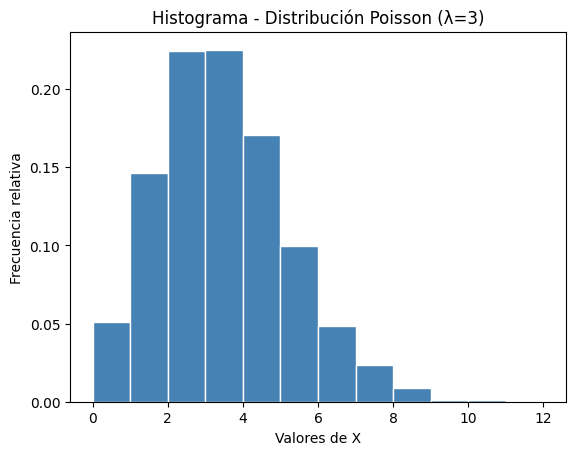

In [12]:

plt.hist(muestra, bins=range(min(muestra), max(muestra)+2),
         density=True, color='steelblue', edgecolor='white')

plt.xlabel("Valores de X")
plt.ylabel("Frecuencia relativa")
plt.title(f"Histograma - Distribución Poisson (λ={lam})")
plt.show()